In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import zipfile, os
from pathlib import Path

print("🔍 Dosya aranıyor...")
search_results = !find /content/drive/MyDrive -name "MultiRes_ConfocFluo_HumanDentin.zip"

if search_results:
    ZIP_PATH = search_results[0]
    print(f"✅ Bulundu: {ZIP_PATH}")
else:
    ZIP_PATH = "/content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip"

EXTRACT_PATH = "/content/dataset"
check = Path(EXTRACT_PATH) / "MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified"

if check.exists():
    print("✅ Dataset zaten açık!")
else:
    print("📦 Açılıyor...")
    os.makedirs(EXTRACT_PATH, exist_ok=True)
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        dosyalar = [f for f in z.namelist() if 'ImagePatches128' in f]
        toplam = len(dosyalar)
        for i, d in enumerate(dosyalar):
            z.extract(d, EXTRACT_PATH)
            if i % 10000 == 0:
                print(f"  {i:,}/{toplam:,} ({i/toplam*100:.0f}%)")
    print("✅ Açıldı!")

Mounted at /content/drive
🔍 Dosya aranıyor...
✅ Bulundu: /content/drive/MyDrive/MultiRes_ConfocFluo_HumanDentin.zip
📦 Açılıyor...
  0/361,873 (0%)
  10,000/361,873 (3%)
  20,000/361,873 (6%)
  30,000/361,873 (8%)
  40,000/361,873 (11%)
  50,000/361,873 (14%)
  60,000/361,873 (17%)
  70,000/361,873 (19%)
  80,000/361,873 (22%)
  90,000/361,873 (25%)
  100,000/361,873 (28%)
  110,000/361,873 (30%)
  120,000/361,873 (33%)
  130,000/361,873 (36%)
  140,000/361,873 (39%)
  150,000/361,873 (41%)
  160,000/361,873 (44%)
  170,000/361,873 (47%)
  180,000/361,873 (50%)
  190,000/361,873 (53%)
  200,000/361,873 (55%)
  210,000/361,873 (58%)
  220,000/361,873 (61%)
  230,000/361,873 (64%)
  240,000/361,873 (66%)
  250,000/361,873 (69%)
  260,000/361,873 (72%)
  270,000/361,873 (75%)
  280,000/361,873 (77%)
  290,000/361,873 (80%)
  300,000/361,873 (83%)
  310,000/361,873 (86%)
  320,000/361,873 (88%)
  330,000/361,873 (91%)
  340,000/361,873 (94%)
  350,000/361,873 (97%)
  360,000/361,873 (99%)
✅

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from pathlib import Path
import tifffile
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import random
import warnings
warnings.filterwarnings('ignore')

DEVICE       = torch.device("cuda")
PATCHES_ROOT = Path("/content/dataset/MultiRes_ConfocFluo_HumanDentin/ImagePatches128/Classified")
SINIFLAR     = ["tubules", "branches", "both"]
SINIF2IDX    = {s: i for i, s in enumerate(SINIFLAR)}
IDX2SINIF    = {i: s for s, i in SINIF2IDX.items()}
COZUNURLUKLER = ["HR", "x2", "x4", "x8"]
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

SINIF_RENKLERI = {
    "tubules" : "#E74C3C",
    "branches": "#27AE60",
    "both"    : "#2980B9"
}

def get_roi(filename):
    for p in Path(filename).stem.split('_'):
        if p.startswith('roi'):
            return p
    return None

def build_file_list(patches_root, siniflar, cozunurluk, roi_listesi):
    dosyalar = []
    for sinif in siniflar:
        klasor = patches_root / sinif / cozunurluk
        if not klasor.exists():
            continue
        for tif in sorted(klasor.glob("*.tif")):
            if get_roi(tif.name) in roi_listesi:
                dosyalar.append((str(tif), SINIF2IDX[sinif]))
    return dosyalar

class DentinDataset(Dataset):
    def __init__(self, dosya_listesi):
        self.dosya_listesi = dosya_listesi
        self.tf = transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize(MEAN, STD)
        ])
    def __len__(self): return len(self.dosya_listesi)
    def __getitem__(self, idx):
        yol, etiket = self.dosya_listesi[idx]
        img = Image.fromarray(tifffile.imread(yol)).convert("RGB")
        return self.tf(img), etiket, yol

def efficientnet_olustur():
    m = models.efficientnet_b0(weights=None)
    in_features = m.classifier[1].in_features
    m.classifier = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 256),
        nn.ReLU(True),
        nn.Dropout(0.2),
        nn.Linear(256, 3)
    )
    return m

def goruntu_denormalize(tensor):
    img = tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(STD) + np.array(MEAN)
    return np.clip(img, 0, 1)

# Modeli yükle (HR)
model = efficientnet_olustur().to(DEVICE)
model.load_state_dict(torch.load(
    "/content/drive/MyDrive/effnet_best_HR.pth", map_location=DEVICE))
model.eval()

print(f"✅ Device : {DEVICE} ({torch.cuda.get_device_name(0)})")
print(f"✅ Model  : EfficientNet-B0 (HR) yüklendi")
print(f"✅ Kurulum tamamlandı!")

✅ Device : cuda (NVIDIA A100-SXM4-40GB)
✅ Model  : EfficientNet-B0 (HR) yüklendi
✅ Kurulum tamamlandı!



SONUÇ: 11/12 doğru (%91.7)


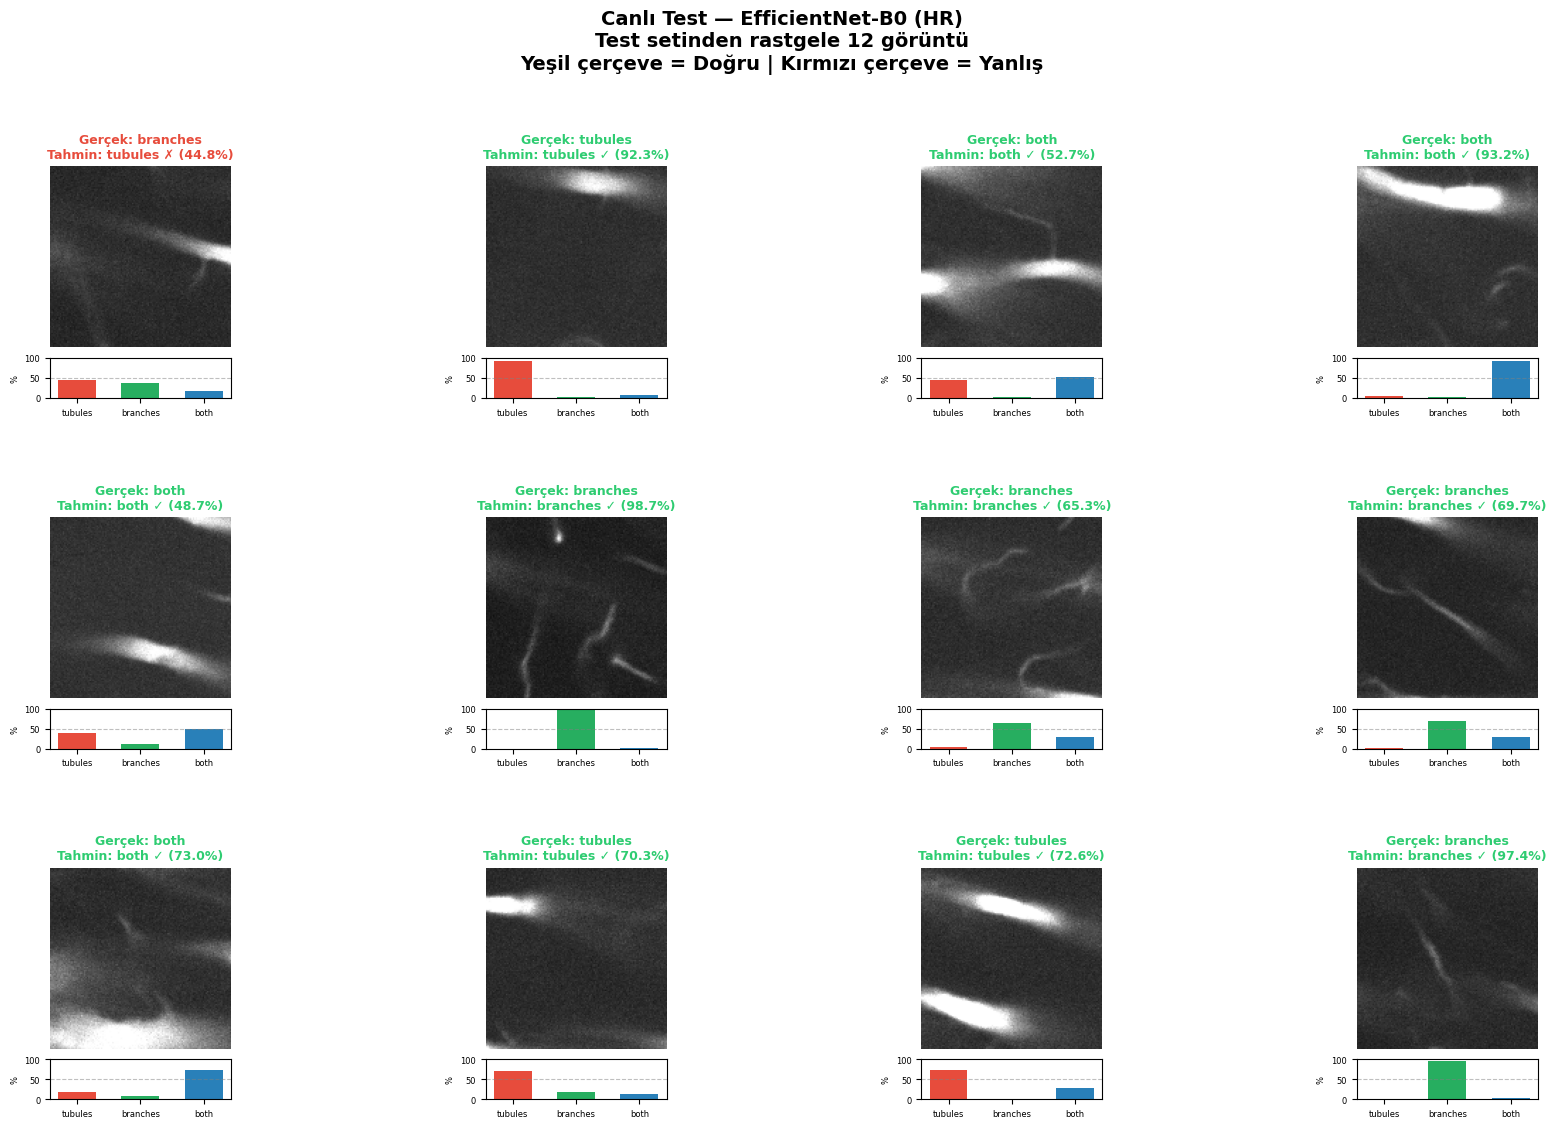

In [ ]:
# ============================================================
# HÜCRE 3: RASTGELe 12 GÖRÜNTÜ — MODELİN TAHMİNLERİ
# ============================================================
test_listesi = build_file_list(
    PATCHES_ROOT, SINIFLAR, "HR", ["roi06"])
random.seed(42)
secilen = random.sample(test_listesi, 12)

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
fig.suptitle("Canlı Test — EfficientNet-B0 (HR)\n"
             "Test setinden rastgele 12 görüntü\n"
             "Yeşil çerçeve = Doğru | Kırmızı çerçeve = Yanlış",
             fontsize=14, fontweight='bold')

dogru = 0

for i, (yol, gercek_idx) in enumerate(secilen):
    satir, sutun = i // 4, i % 4
    ax = axes[satir, sutun]

    img_pil = Image.fromarray(tifffile.imread(yol)).convert("RGB")
    tf_test = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(MEAN, STD)
    ])
    tensor = tf_test(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        cikti = model(tensor)
        prob  = torch.softmax(cikti, dim=1)[0].cpu().numpy()
        tahmin_idx = int(prob.argmax())

    gercek_sinif = IDX2SINIF[gercek_idx]
    tahmin_sinif = IDX2SINIF[tahmin_idx]
    guven        = prob[tahmin_idx] * 100
    dogru_mu     = tahmin_idx == gercek_idx

    if dogru_mu:
        dogru += 1

    # Görüntü
    ax.imshow(np.array(img_pil), cmap='gray')

    # Çerçeve
    cerceve_rengi = '#2ECC71' if dogru_mu else '#E74C3C'
    for spine in ax.spines.values():
        spine.set_edgecolor(cerceve_rengi)
        spine.set_linewidth(6)

    # Başlık
    isaret = "✓" if dogru_mu else "✗"
    ax.set_title(
        f"Gerçek: {gercek_sinif}\n"
        f"Tahmin: {tahmin_sinif} {isaret} ({guven:.1f}%)",
        fontsize=9, color=cerceve_rengi, fontweight='bold')

    # Olasılık barları (numeric index kullan)
    ax2 = ax.inset_axes([0, -0.28, 1, 0.22])
    x_pos = np.arange(3)
    renkler = [SINIF_RENKLERI[s] for s in SINIFLAR]
    ax2.bar(x_pos, prob * 100, color=renkler, width=0.6)
    ax2.set_xticks(x_pos)
    ax2.set_xticklabels(SINIFLAR, fontsize=6)
    ax2.set_ylim(0, 100)
    ax2.set_ylabel("%", fontsize=6)
    ax2.tick_params(axis='y', labelsize=6)
    ax2.axhline(y=50, color='gray', ls='--', lw=0.8, alpha=0.5)

    ax.axis('off')

toplam = len(secilen)
print(f"\n{'='*50}")
print(f"SONUÇ: {dogru}/{toplam} doğru (%{dogru/toplam*100:.1f})")
print(f"{'='*50}")

plt.tight_layout(pad=3.0)
plt.savefig("canli_test_12goruntu.png", dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ============================================================
# HÜCRE 4: AYNI GÖRÜNTÜ — 4 ÇÖZÜNÜRLÜKTE MODEL TAHMİNİ
# ============================================================

# Her çözünürlük için model yükle
modeller = {}
for coz in COZUNURLUKLER:
    m = efficientnet_olustur().to(DEVICE)
    m.load_state_dict(torch.load(
        f"/content/drive/MyDrive/effnet_best_{coz}.pth", map_location=DEVICE))
    m.eval()
    modeller[coz] = m
    print(f"✅ {coz} modeli yüklendi")

# Her sınıftan 1 örnek seç (test setinden)
tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

fig, axes = plt.subplots(3, 4, figsize=(18, 14))
fig.suptitle("Canlı Test — Aynı Bölge, 4 Farklı Çözünürlük\n"
             "Her satır bir sınıf | Her sütun bir çözünürlük",
             fontsize=14, fontweight='bold')

for satir, sinif in enumerate(SINIFLAR):
    # Bu sınıftan HR'de bir dosya seç
    hr_liste = build_file_list(PATCHES_ROOT, [sinif], "HR", ["roi06"])
    if not hr_liste:
        continue
    secilen_dosya = hr_liste[0][0]
    dosya_adi = Path(secilen_dosya).name

    for sutun, coz in enumerate(COZUNURLUKLER):
        ax = axes[satir, sutun]

        # Aynı dosya adını farklı çözünürlükte bul
        coz_yol = PATCHES_ROOT / sinif / coz / dosya_adi
        if not coz_yol.exists():
            ax.text(0.5, 0.5, "Bulunamadı", ha='center', va='center')
            ax.axis('off')
            continue

        img_pil = Image.fromarray(tifffile.imread(str(coz_yol))).convert("RGB")
        tensor  = tf(img_pil).unsqueeze(0).to(DEVICE)

        with torch.no_grad():
            cikti = modeller[coz](tensor)
            prob  = torch.softmax(cikti, dim=1)[0].cpu().numpy()
            tahmin_idx = prob.argmax()

        tahmin_sinif = IDX2SINIF[tahmin_idx]
        guven        = prob[tahmin_idx] * 100
        dogru_mu     = tahmin_sinif == sinif

        img_np = np.array(img_pil)
        ax.imshow(img_np, cmap='gray')

        cerceve_rengi = '#2ECC71' if dogru_mu else '#E74C3C'
        for spine in ax.spines.values():
            spine.set_edgecolor(cerceve_rengi)
            spine.set_linewidth(6)

        isaret = "✓" if dogru_mu else "✗"
        ax.set_title(
            f"{coz} | Gerçek: {sinif}\n"
            f"Tahmin: {tahmin_sinif} {isaret} ({guven:.1f}%)",
            fontsize=9, color=cerceve_rengi, fontweight='bold')
        ax.axis('off')

plt.tight_layout()
plt.savefig("canli_test_4cozunurluk.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ 4 çözünürlük canlı test tamamlandı!")

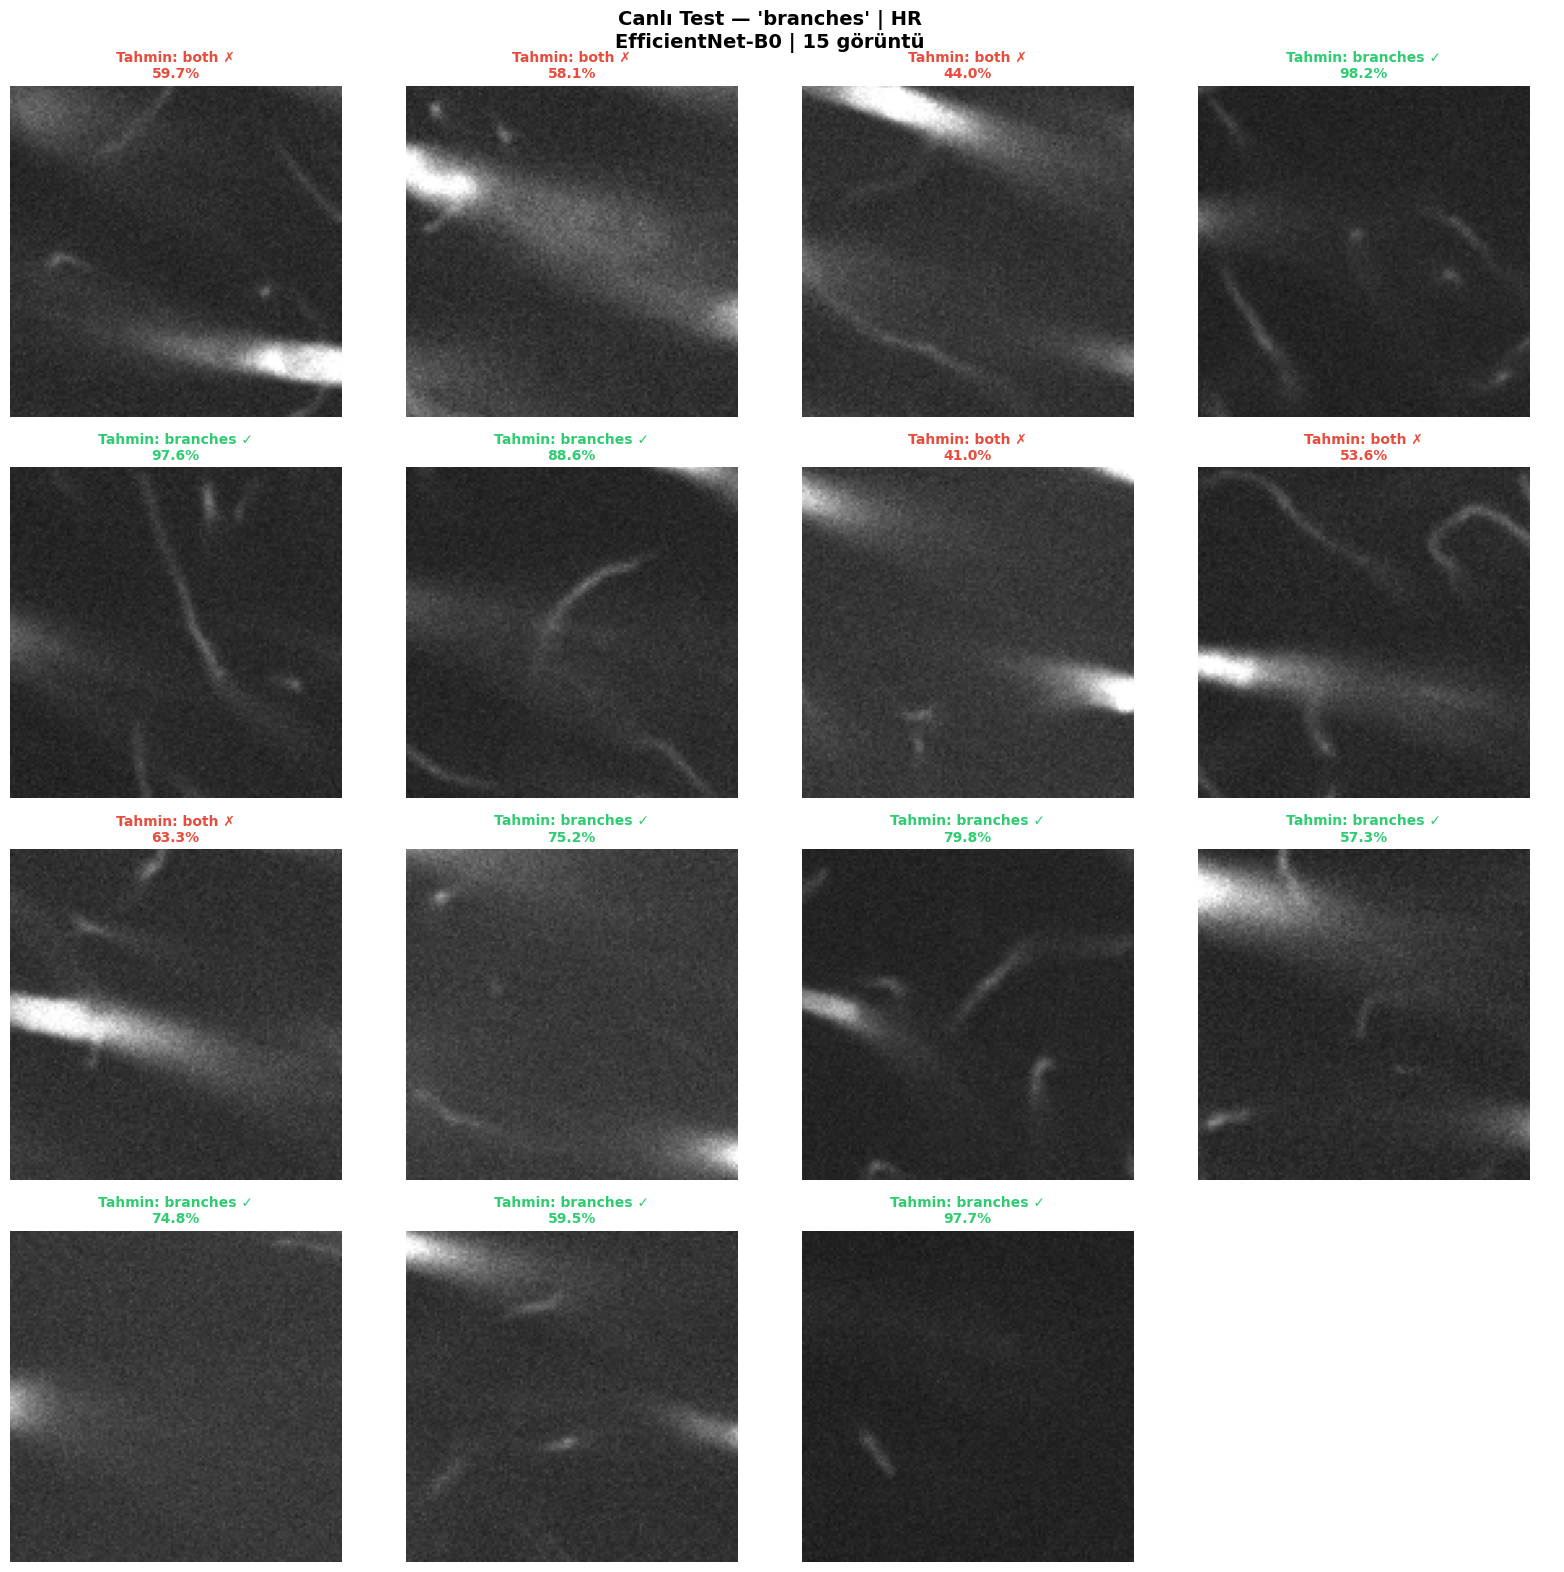


✅ 9/15 doğru (%60.0)

💡 Değişkenleri değiştirip tekrar çalıştır:
   SINIF : tubules | branches | both
   COZ   : HR | x2 | x4 | x8
   SAYI  : istediğin kadar


In [ ]:
# ============================================================
# HÜCRE 5: KENDİN SEÇ — MODEL TAHMİN ETSİN
# ============================================================
GORMEK_ISTEDIGIM_SINIF = "branches"  # "tubules", "branches", "both"
GORMEK_ISTEDIGIM_COZ   = "HR"       # "HR", "x2", "x4", "x8"
GORUNTU_SAYISI         = 15          # istediğin kadar yaz (max ~50)

tf_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD)
])

liste = build_file_list(
    PATCHES_ROOT, [GORMEK_ISTEDIGIM_SINIF],
    GORMEK_ISTEDIGIM_COZ, ["roi06"])

random.seed(None)
secilen = random.sample(liste, min(GORUNTU_SAYISI, len(liste)))
gercek_sayi = len(secilen)

# Grid boyutunu otomatik hesapla
sutun_sayisi = min(4, gercek_sayi)
satir_sayisi = int(np.ceil(gercek_sayi / sutun_sayisi))

fig, axes = plt.subplots(satir_sayisi, sutun_sayisi,
                         figsize=(sutun_sayisi * 4, satir_sayisi * 4))
if satir_sayisi == 1 and sutun_sayisi == 1:
    axes = np.array([[axes]])
elif satir_sayisi == 1:
    axes = axes.reshape(1, -1)
elif sutun_sayisi == 1:
    axes = axes.reshape(-1, 1)

fig.suptitle(
    f"Canlı Test — '{GORMEK_ISTEDIGIM_SINIF}' | {GORMEK_ISTEDIGIM_COZ}\n"
    f"EfficientNet-B0 | {gercek_sayi} görüntü",
    fontsize=14, fontweight='bold')

dogru = 0

for i in range(gercek_sayi):
    satir = i // sutun_sayisi
    sutun = i % sutun_sayisi
    ax = axes[satir, sutun]

    yol, gercek_idx = secilen[i]
    img_pil = Image.fromarray(tifffile.imread(yol)).convert("RGB")
    tensor  = tf_test(img_pil).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        cikti      = modeller[GORMEK_ISTEDIGIM_COZ](tensor)
        prob       = torch.softmax(cikti, dim=1)[0].cpu().numpy()
        tahmin_idx = int(prob.argmax())

    tahmin_sinif = IDX2SINIF[tahmin_idx]
    guven        = prob[tahmin_idx] * 100
    dogru_mu     = (tahmin_sinif == GORMEK_ISTEDIGIM_SINIF)
    if dogru_mu: dogru += 1

    ax.imshow(np.array(img_pil), cmap='gray')
    renk = '#2ECC71' if dogru_mu else '#E74C3C'
    for spine in ax.spines.values():
        spine.set_edgecolor(renk)
        spine.set_linewidth(5)
    isaret = "✓" if dogru_mu else "✗"
    ax.set_title(f"Tahmin: {tahmin_sinif} {isaret}\n{guven:.1f}%",
                 fontsize=10, color=renk, fontweight='bold')
    ax.axis('off')

# Boş eksenler
for j in range(gercek_sayi, satir_sayisi * sutun_sayisi):
    axes[j // sutun_sayisi, j % sutun_sayisi].axis('off')

plt.tight_layout()
plt.savefig(f"canli_test_{GORMEK_ISTEDIGIM_SINIF}_{GORMEK_ISTEDIGIM_COZ}.png",
            dpi=150, bbox_inches='tight')
plt.show()
print(f"\n✅ {dogru}/{gercek_sayi} doğru (%{dogru/gercek_sayi*100:.1f})")
print(f"\n💡 Değişkenleri değiştirip tekrar çalıştır:")
print(f"   SINIF : tubules | branches | both")
print(f"   COZ   : HR | x2 | x4 | x8")
print(f"   SAYI  : istediğin kadar")